# Chapter 4: Regression and Prediction

## Summary

Regression is one of the most important statistical techniques used in data science and machine learning. It helps describe relationships between variables and enables prediction of future outcomes.

This chapter introduces simple linear regression, multiple linear regression, prediction, residual analysis, and model evaluation. Regression models are widely used in business analytics, finance, healthcare, engineering, and machine learning applications.

Understanding regression provides a foundation for predictive modeling and helps explain how input variables influence outcomes.

## Learning Objectives

After completing this chapter, students should be able to:

- Understand regression analysis.
- Explain simple linear regression.
- Interpret regression coefficients.
- Understand fitted values and residuals.
- Apply multiple linear regression.
- Evaluate regression performance.
- Understand prediction using regression models.
- Interpret regression outputs.

## Theory: Simple Linear Regression

Simple Linear Regression models the relationship between one predictor variable and one target variable.

General Equation:

Y = β₀ + β₁X

Where:

- Y = Target Variable
- X = Predictor Variable
- β₀ = Intercept
- β₁ = Slope

The objective is to find the line that best fits the observed data.

Regression helps explain how changes in X affect Y.

In [2]:
import pandas as pd

data = pd.DataFrame({
    'Experience': [1, 2, 3, 4, 5, 6],
    'Salary': [3000, 3500, 4500, 5000, 6000, 7000]
})

data

,Experience,Salary
0,1,3000
1,2,3500
2,3,4500
3,4,5000
4,5,6000
5,6,7000


In [3]:
from sklearn.linear_model import LinearRegression

X = data[['Experience']]
y = data['Salary']

model = LinearRegression()

model.fit(X, y)

print("Intercept:")
print(model.intercept_)

print("\nCoefficient:")
print(model.coef_[0])

Intercept:
2033.333333333333

Coefficient:
800.0


## Code Explanation

The code creates a simple linear regression model using years of experience to predict salary.

The intercept represents the predicted salary when experience is zero.

The coefficient indicates how much salary increases for each additional year of experience.

In [4]:
predictions = model.predict(X)

print(predictions)

[2833.33333333 3633.33333333 4433.33333333 5233.33333333 6033.33333333
 6833.33333333]


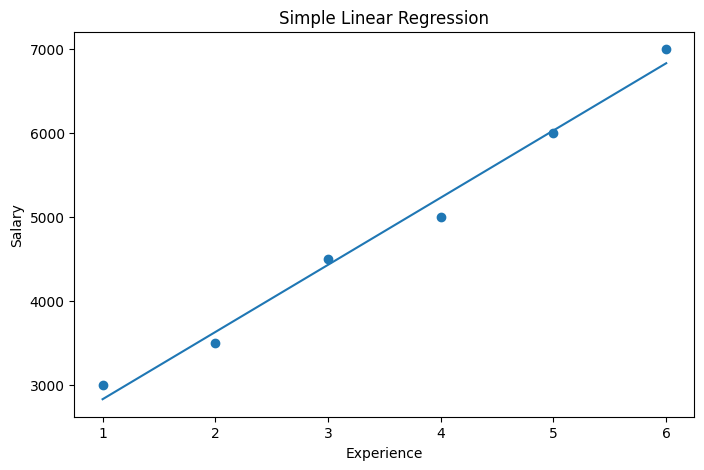

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    data['Experience'],
    data['Salary']
)

plt.plot(
    data['Experience'],
    predictions
)

plt.title("Simple Linear Regression")
plt.xlabel("Experience")
plt.ylabel("Salary")

plt.show()

## Theory: Fitted Values and Residuals

### Fitted Values

Fitted values are the predicted values generated by the regression model.

### Residuals

Residuals are the differences between observed values and predicted values.

Residual = Actual Value − Predicted Value

Residual analysis helps evaluate model performance and identify potential issues.

In [6]:
residuals = y - predictions

print("Residuals:")
print(residuals)

Residuals:
0    166.666667
1   -133.333333
2     66.666667
3   -233.333333
4    -33.333333
5    166.666667
Name: Salary, dtype: float64


## Theory: Multiple Linear Regression

Multiple Linear Regression extends simple linear regression by using multiple predictor variables.

General Equation:

Y = β₀ + β₁X₁ + β₂X₂ + ... + βₙXₙ

Where:

- Y = Target Variable
- X₁, X₂, ... = Predictor Variables
- β = Regression Coefficients

Multiple regression is commonly used because real-world outcomes are usually influenced by multiple factors simultaneously.

In [7]:
data_multi = pd.DataFrame({
    'Experience': [1, 2, 3, 4, 5, 6],
    'Education': [12, 12, 14, 14, 16, 18],
    'Salary': [3000, 3500, 4500, 5000, 6000, 7000]
})

X_multi = data_multi[
    ['Experience', 'Education']
]

y_multi = data_multi['Salary']

multi_model = LinearRegression()

multi_model.fit(
    X_multi,
    y_multi
)

print("Intercept:")
print(multi_model.intercept_)

print("\nCoefficients:")
print(multi_model.coef_)

Intercept:
-499.9999999999991

Coefficients:
[500. 250.]


## Code Explanation

This model uses two predictors:

- Experience
- Education

The regression coefficients indicate how much the salary changes when one predictor increases while the others remain constant.

Multiple regression generally provides more realistic predictions because multiple variables influence the outcome.

## Theory: Model Assessment

After fitting a regression model, it is important to evaluate its performance.

Common evaluation metrics include:

### R² Score

Measures the proportion of variance explained by the model.

### Mean Absolute Error (MAE)

Measures the average absolute prediction error.

### Mean Squared Error (MSE)

Measures the average squared prediction error.

### Root Mean Squared Error (RMSE)

Provides prediction error in the original units.

In [8]:
from sklearn.metrics import r2_score

pred_multi = multi_model.predict(
    X_multi
)

r2 = r2_score(
    y_multi,
    pred_multi
)

print("R² Score:")
print(r2)

R² Score:
1.0


In [9]:
from sklearn.metrics import r2_score

pred_multi = multi_model.predict(
    X_multi
)

r2 = r2_score(
    y_multi,
    pred_multi
)

print("R² Score:")
print(r2)

R² Score:
1.0


## Theory: Train-Test Split

Machine learning models should be evaluated on data that was not used during training.

The Train-Test Split divides data into:

### Training Set

Used to train the model.

### Testing Set

Used to evaluate model performance.

This approach helps estimate how well a model generalizes to unseen data.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_multi,
    y_multi,
    test_size=0.3,
    random_state=42
)

print("Training Samples:")
print(len(X_train))

print("\nTesting Samples:")
print(len(X_test))

Training Samples:
4

Testing Samples:
2


In [11]:
test_model = LinearRegression()

test_model.fit(
    X_train,
    y_train
)

test_predictions = test_model.predict(
    X_test
)

print("Predictions:")
print(test_predictions)

Predictions:
[3000. 3500.]


## Discussion

Multiple Linear Regression improves predictive performance by incorporating multiple predictors.

Evaluation metrics such as R², MAE, and MSE help quantify model quality and prediction accuracy.

Train-Test Splits are essential because they help prevent overly optimistic performance estimates and provide a more realistic evaluation of model behavior.

These techniques form the foundation of predictive modeling in machine learning.

## Theory: Cross Validation

Cross Validation is a model evaluation technique that repeatedly splits data into training and validation sets.

The most common approach is K-Fold Cross Validation.

Procedure:

1. Divide data into K subsets.
2. Train the model on K-1 subsets.
3. Validate on the remaining subset.
4. Repeat K times.
5. Average the results.

Cross Validation provides a more reliable estimate of model performance than a single train-test split.

In [13]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    LinearRegression(),
    X_multi,
    y_multi,
    cv=3
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage Score:")
print(cv_scores.mean())

Cross Validation Scores:
[1. 1. 1.]

Average Score:
1.0


## Theory: Model Selection

Model selection is the process of choosing the most appropriate model for a given problem.

Important considerations include:

- Prediction accuracy
- Model complexity
- Interpretability
- Computational cost

A simpler model is often preferred when performance is similar because simpler models are easier to understand and maintain.

## Theory: Prediction vs Explanation

Regression models can be used for two different purposes.

### Prediction

The objective is to accurately predict future outcomes.

Examples:

- House price prediction
- Sales forecasting
- Demand prediction

### Explanation

The objective is to understand relationships between variables.

Examples:

- Impact of education on salary
- Relationship between advertising and sales

The same regression model may be used for both purposes, but the interpretation differs.

## Theory: Multicollinearity

Multicollinearity occurs when predictor variables are highly correlated with one another.

Problems caused by multicollinearity:

- Unstable coefficients
- Difficult interpretation
- Reduced reliability

Machine learning models may still perform well in prediction tasks even when multicollinearity exists, but interpretation becomes more difficult.

In [14]:
correlation_matrix = data_multi.corr()

print(correlation_matrix)

            Experience  Education   Salary
Experience    1.000000   0.960183  0.99410
Education     0.960183   1.000000  0.98482
Salary        0.994100   0.984820  1.00000


## Regression Diagnostics

Regression diagnostics help evaluate whether model assumptions are satisfied.

Common diagnostic checks include:

### Residual Analysis

Residuals should be randomly distributed.

### Linearity

Relationships should be approximately linear.

### Homoscedasticity

Residual variance should remain relatively constant.

### Independence

Observations should be independent.

### Normality

Residuals should approximately follow a normal distribution.

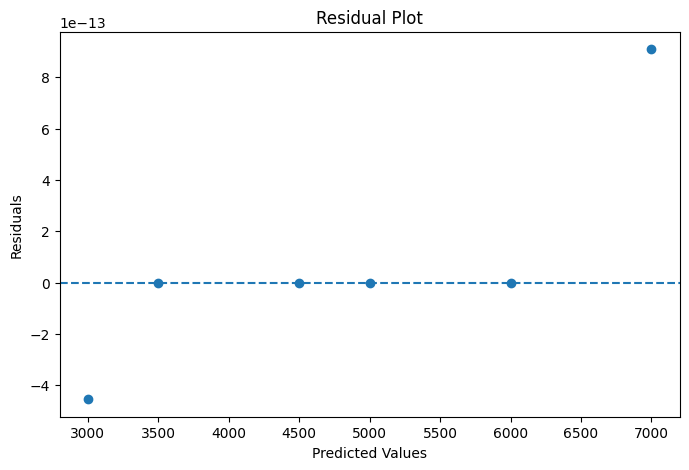

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(
    pred_multi,
    y_multi - pred_multi
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()

## Discussion

Regression analysis is one of the most powerful and widely used techniques in data science.

Simple and Multiple Linear Regression help explain relationships between variables and generate predictions.

Model evaluation metrics such as R², MAE, and MSE provide quantitative measures of performance, while diagnostics help assess whether model assumptions are satisfied.

Cross Validation improves performance estimation and helps prevent overfitting.

These concepts form the basis of predictive analytics and machine learning.

## Conclusion

Regression and Prediction are fundamental concepts in statistics, machine learning, and data science.

This chapter introduced Simple Linear Regression, Multiple Linear Regression, model evaluation, train-test splits, cross validation, model selection, multicollinearity, and regression diagnostics.

Regression models help both explain relationships between variables and generate predictions for future observations.

A strong understanding of regression analysis provides the foundation for more advanced predictive modeling techniques.